In [67]:
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt
from scipy.signal import wiener

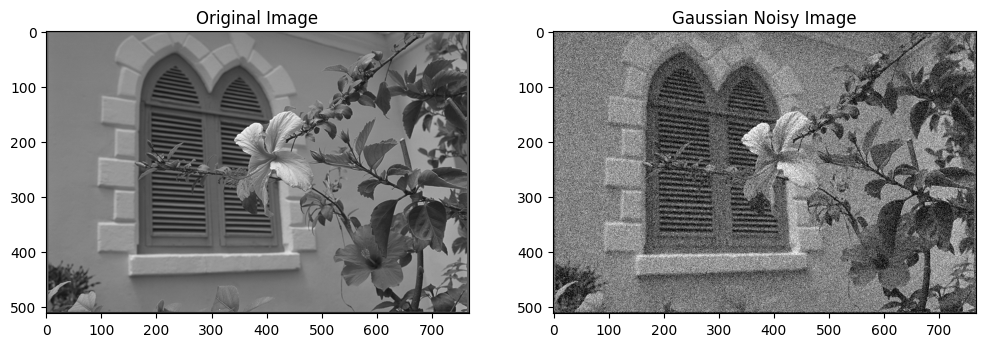

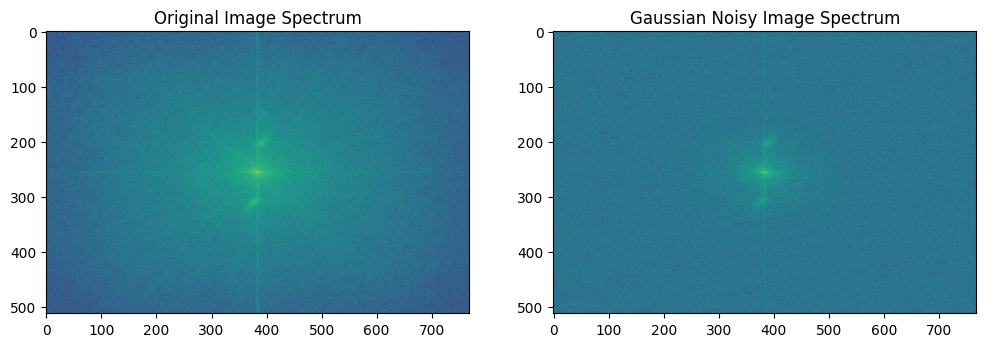

In [68]:
img = cv2.imread("./data/kodim07.png")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

# apply Gaussian noise
mean = 0
var = 1000
sigma = var**0.5
gaussian_noise = np.random.normal(mean, sigma, img_gray.shape)
gaussian_noisy_img = img_gray + gaussian_noise
gaussian_noisy_img = np.clip(gaussian_noisy_img, 0, 255).astype(np.uint8)

# plot 
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1), plt.imshow(img_gray, cmap='gray'), plt.title('Original Image')
plt.subplot(1, 2, 2), plt.imshow(gaussian_noisy_img, cmap='gray'), plt.title('Gaussian Noisy Image')
plt.show()

img_original_spectrum = np.fft.fftshift(np.fft.fft2(img_gray))
img_noisy_spectrum = np.fft.fftshift(np.fft.fft2(gaussian_noisy_img))

plt.figure(figsize=(12, 6))
plt.subplot(1,2,1), plt.imshow(20 * np.log(np.abs(img_original_spectrum)+1)), plt.title('Original Image Spectrum')
plt.subplot(1,2,2), plt.imshow(20 * np.log(np.abs(img_noisy_spectrum)+1)), plt.title('Gaussian Noisy Image Spectrum')
plt.show()

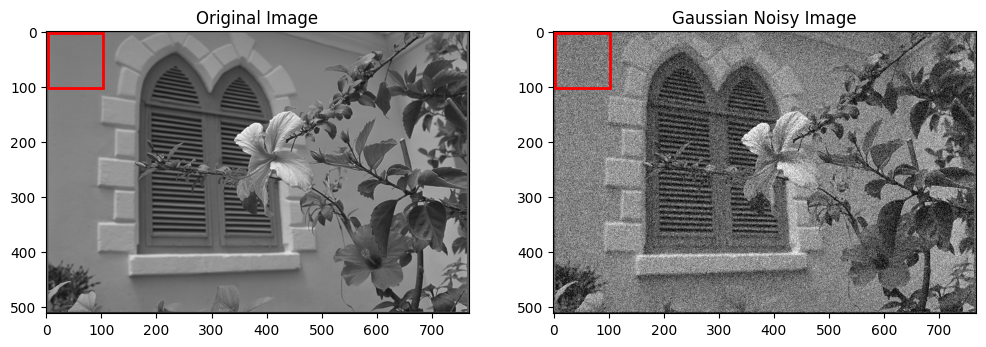

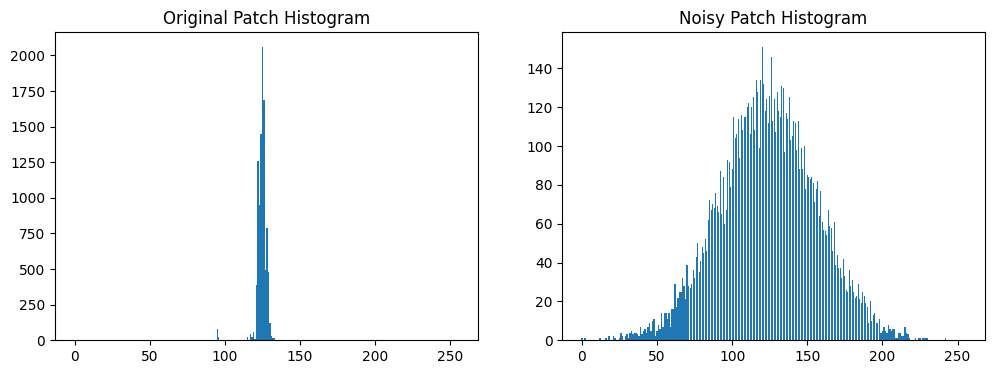

In [69]:
# Estrai direttamente il rettangolo 100x100
original_patch = img_gray[3:103, 3:103]
noisy_patch = gaussian_noisy_img[3:103, 3:103]

# plot the images highliting the patch with a red rectangle
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1), plt.imshow(img_gray, cmap='gray'), plt.title('Original Image')
plt.gca().add_patch(plt.Rectangle((3, 3), 100, 100, edgecolor='red', facecolor='none', linewidth=2))
plt.subplot(1, 2, 2), plt.imshow(gaussian_noisy_img, cmap='gray'), plt.title('Gaussian Noisy Image')
plt.gca().add_patch(plt.Rectangle((3, 3), 100, 100, edgecolor='red', facecolor='none', linewidth=2))
plt.show()


# compute the histogram of the original and noisy patches
original_hist = cv2.calcHist([original_patch], [0], None, [256], [0, 256])
noisy_hist = cv2.calcHist([noisy_patch], [0], None, [256], [0, 256])    
# plot the histograms as bar charts
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1), plt.bar(range(256), original_hist.flatten()), plt.title('Original Patch Histogram')
plt.subplot(1, 2, 2), plt.bar(range(256), noisy_hist.flatten()), plt.title('Noisy Patch Histogram')
plt.show()

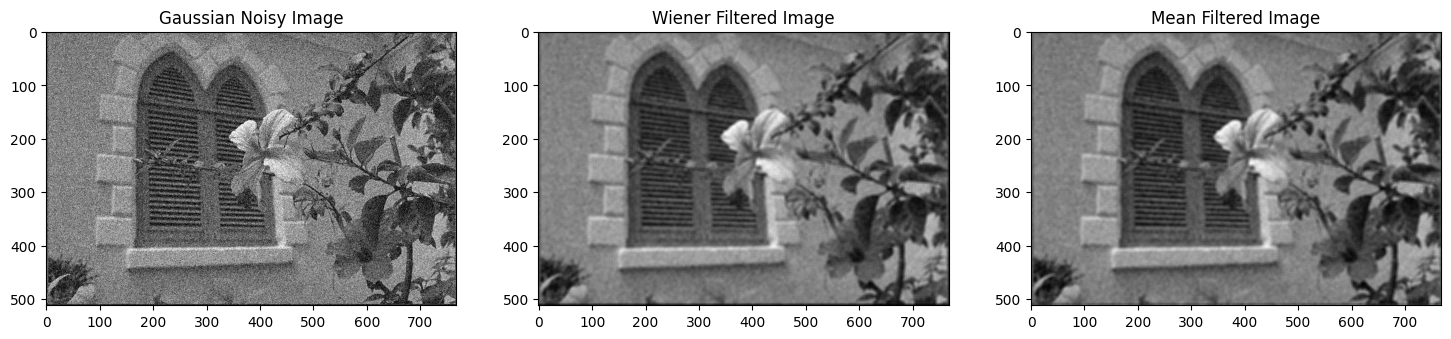

In [70]:
# apply Wiener filter to the noisy image
wiener_filtered_img = wiener(gaussian_noisy_img, (7, 7), noise=var)
wiener_filtered_img = np.clip(wiener_filtered_img, 0, 255).astype(np.uint8) 

# apply classic mean filter to the noisy image
mean_filtered_img = cv2.blur(gaussian_noisy_img, (7, 7))
mean_filtered_img = np.clip(mean_filtered_img, 0, 255).astype(np.uint8)
# plot the original, noisy and filtered images
plt.figure(figsize=(18, 6))
plt.subplot(1, 3, 1), plt.imshow(gaussian_noisy_img, cmap='gray'), plt.title('Gaussian Noisy Image')
plt.subplot(1, 3, 2), plt.imshow(wiener_filtered_img, cmap='gray'), plt.title('Wiener Filtered Image')
plt.subplot(1, 3, 3), plt.imshow(mean_filtered_img, cmap='gray'), plt.title('Mean Filtered Image')
plt.show()